In [1]:
import os
import numpy as np
import sys
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE, train_ae
from core.dataset import TIFFDataset
from utils.feature_analysis import UMAP_train, patch_csv_to_AE_latent, patch_2_normed_tensor,data_to_latents, kmeans_latents,latent_to_umap,UMAP_train,DBSCAN_cluster,kmeans_cluster,dataloader_model_latents,add_features_to_latent
from utils.plotting_utils import umap_2Dplot, cluster_2Dplot


In [3]:
root_dir = '/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_correctloader_ch1_ps32_latdim_8_20251203_2323'
patch_label_df = pd.read_csv(os.path.join(root_dir, 'patch_label_df_lat9umap2.csv'))
lat8_margaret_label_121922 = pd.read_csv(os.path.join(root_dir, 'lat8_margaret_label_121922.csv'))

latents_lat8_2d = joblib.load(os.path.join(root_dir, "pax_wholecell_data_latents_lat8_2d.pkl"))



In [4]:
tab10_colors = [
    "#1f77b4",  # 0 - blue
    "#ff7f0e",  # 1 - orange
    "#2ca02c",  # 2 - green
    "#d62728",  # 3 - red
    "#9467bd",  # 4 - purple
    "#8c564b",  # 5 - brown
    "#e377c2",  # 6 - pink
    "#7f7f7f",  # 7 - gray
    "#bcbd22",  # 8 - olive
    "#17becf",  # 9 - cyan
]

In [5]:
lat8_margaret_label_121922['classification'].unique()

array(['No adhesion', 'focal adhesion', 'Nascent Adhesion',
       'fibrillar adhesion', 'focal complex', 'Uncertain'], dtype=object)

In [6]:
classification_label_order = [
    "Nascent Adhesion",
    "focal complex",
    "focal adhesion",
    "fibrillar adhesion",
    "No adhesion",
    "Uncertain",
]


classification_label_to_color = {
    cls: tab10_colors[i]
    for i, cls in enumerate(classification_label_order)
}

fa_label_to_id = {
    cls: i
    for i, cls in enumerate(classification_label_order)
}

lat8_margaret_label_121922["FA_type_id"] = (
    lat8_margaret_label_121922["classification"]
        .map(fa_label_to_id)
)

In [7]:
position_label_order = [
    "Cell Protruding Edge",
    "Cell Periphery/other",
    "Lamella",
    "Cell Body",
    "No Category/uncertain",
]

position_label_to_color = {
    cls: tab10_colors[i]
    for i, cls in enumerate(position_label_order)
}

position_label_to_id = {
    cls: i
    for i, cls in enumerate(position_label_order)
}

lat8_margaret_label_121922["position_id"] = (
    lat8_margaret_label_121922["Position"]
        .map(position_label_to_id)
)

In [8]:
lat8_margaret_label_121922.columns

Index(['Unnamed: 0', 'unique_ID', 'lat_d0', 'lat_d1', 'lat_d2', 'lat_d3',
       'lat_d4', 'lat_d5', 'lat_d6', 'lat_d7', 'UMAP_d0', 'UMAP_d1',
       'dist_cell_edge', 'front_flag', 'Position', 'classification',
       'group_ID', 'group', 'FA_type_id', 'position_id'],
      dtype='object')

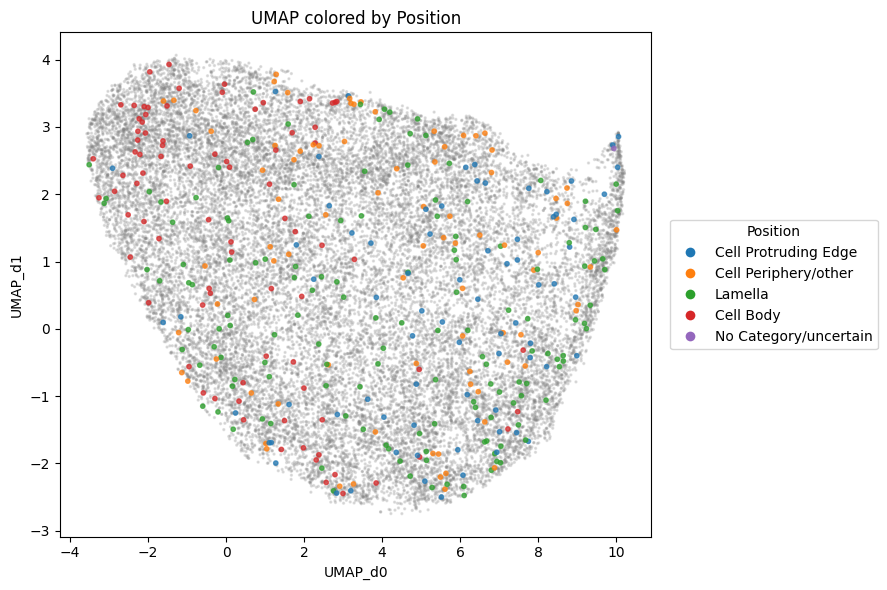

In [9]:
plt.figure(figsize=(9, 6))

plt.scatter(latents_lat8_2d[:,0] , latents_lat8_2d[:,1] , c=5-patch_label_df['group_labels']*0+2, cmap='tab20', alpha=0.2, s=2, vmin=0, vmax=10)  

plt.scatter(
    lat8_margaret_label_121922["UMAP_d0"],
    lat8_margaret_label_121922["UMAP_d1"],
    c=lat8_margaret_label_121922["Position"].map(position_label_to_color),
    s=10,
    alpha=0.7
)

plt.xlabel("UMAP_d0")
plt.ylabel("UMAP_d1")
plt.title("UMAP colored by Position")

# legend
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=position_label_to_color[label],
           markeredgecolor="none",
           markersize=7, label=label)
    for label in position_label_order
]
plt.legend(
    handles=handles,
    title="Position",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)
plt.tight_layout()
plt.show()


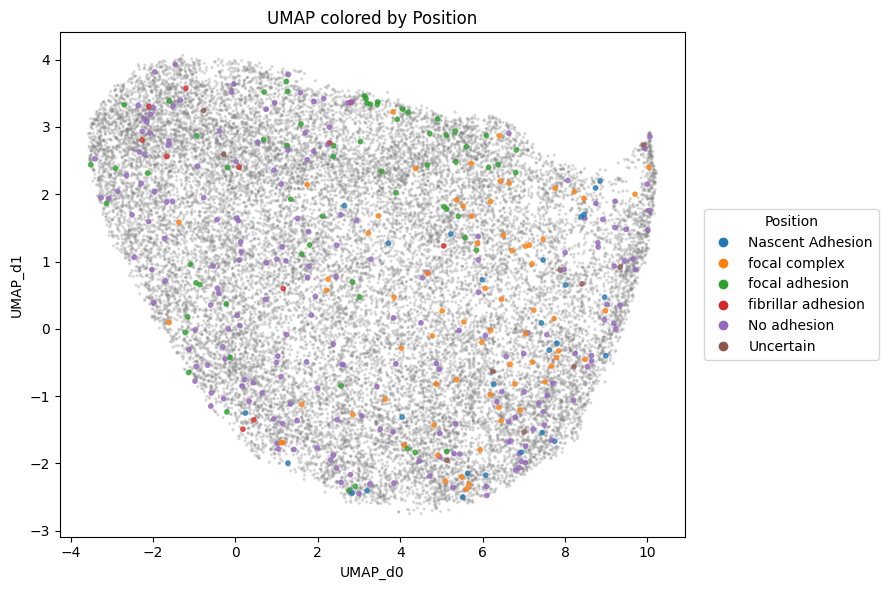

In [10]:

plt.figure(figsize=(9, 6))

plt.scatter(latents_lat8_2d[:,0] , latents_lat8_2d[:,1] , c=5-patch_label_df['group_labels']*0+2, cmap='tab20', alpha=0.2, s=2, vmin=0, vmax=10)  

plt.scatter(
    lat8_margaret_label_121922["UMAP_d0"],
    lat8_margaret_label_121922["UMAP_d1"],
    c=lat8_margaret_label_121922["classification"].map(classification_label_to_color),
    s=10,
    alpha=0.7
)

plt.xlabel("UMAP_d0")
plt.ylabel("UMAP_d1")
plt.title("UMAP colored by Position")

# legend
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=classification_label_to_color[label],
           markeredgecolor="none",
           markersize=7, label=label)
    for label in classification_label_order
]
plt.legend(
    handles=handles,
    title="Position",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)
plt.tight_layout()
plt.show()


In [11]:
df_clean = lat8_margaret_label_121922[lat8_margaret_label_121922["classification"] != "Uncertain"].copy()


In [12]:
df_clean.columns

Index(['Unnamed: 0', 'unique_ID', 'lat_d0', 'lat_d1', 'lat_d2', 'lat_d3',
       'lat_d4', 'lat_d5', 'lat_d6', 'lat_d7', 'UMAP_d0', 'UMAP_d1',
       'dist_cell_edge', 'front_flag', 'Position', 'classification',
       'group_ID', 'group', 'FA_type_id', 'position_id'],
      dtype='object')

In [13]:
lat_cols = [f"lat_d{i}" for i in range(8)]


X = df_clean[lat_cols].values
y_FA_class = df_clean["classification"].values
y_position = df_clean["Position"].values

y_FA_class_enc = df_clean["FA_type_id"].values
y_position_enc = df_clean["position_id"].values


In [129]:
full_X = lat8_margaret_label_121922[lat_cols].values
full_y_FA_class = lat8_margaret_label_121922["classification"].values
full_y_position = lat8_margaret_label_121922["Position"].values

full_y_FA_class_enc = lat8_margaret_label_121922["FA_type_id"].values
full_y_position_enc = lat8_margaret_label_121922["position_id"].values

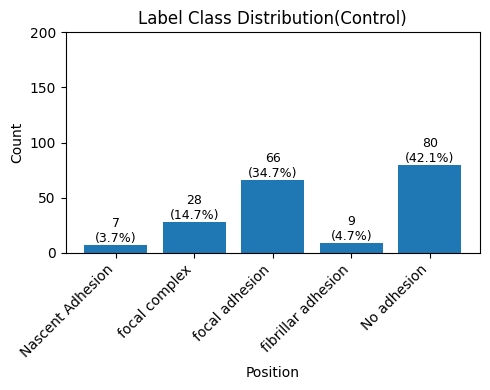

In [136]:
# plot without the  "no adhesion group"
mask = np.logical_and(np.logical_and(full_y_FA_class_enc!=40, lat8_margaret_label_121922['group'].values == 'control'),lat8_margaret_label_121922['classification'].values!= "Uncertain")>0

pred_ids = full_y_FA_class_enc[mask]


plt.figure(figsize=(5, 4))

counts, bins, patches = plt.hist(
    pred_ids,
    bins=np.arange(n_classes + 1) - 0.5,
    rwidth=0.8
)

total = counts.sum()

# Add percentage labels
for count, patch in zip(counts, patches):
    if count > 0:
        percentage = 100 * count / total
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        # inside the same loop
        plt.text(
            x, y,
            f"{int(count)}\n({percentage:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=9
        )


plt.xticks(
    np.arange(n_classes),
    class_names,
    rotation=45,
    ha="right"
)

plt.xlabel("Position")
plt.ylabel("Count")
plt.title("Label Class Distribution(Control)")
plt.ylim([0,200])
plt.tight_layout()
plt.show()

In [90]:
lat8_margaret_label_121922

,Unnamed: 0,unique_ID,lat_d0,lat_d1,lat_d2,lat_d3,lat_d4,lat_d5,lat_d6,lat_d7,UMAP_d0,UMAP_d1,dist_cell_edge,front_flag,Position,classification,group_ID,group,FA_type_id,position_id
0,0,control-f0001x0592y0560ps32.tif,-0.983314,-2.404803,-3.736503,6.555636,0.042419,6.967061,-8.542937,-4.755290,4.961792,-1.905312,51.0,0.0,Cell Body,No adhesion,0,control,4,3
1,1,control-f0001x0688y0848ps32.tif,-4.863095,-3.715334,-3.399110,5.652102,0.032057,8.218933,-11.530948,-4.186346,6.798612,-2.101816,105.0,0.0,Lamella,No adhesion,0,control,4,2
2,2,control-f0001x0592y0592ps32.tif,-1.803649,-2.869361,-1.006975,3.253512,0.877270,5.041645,-6.751046,-2.243623,2.566194,-2.282539,83.0,0.0,Cell Body,No adhesion,0,control,4,3
3,3,control-f0001x0368y0528ps32.tif,-3.296754,-2.140397,1.562945,5.854156,4.291277,12.685116,-13.712293,-2.580447,7.103175,-0.058455,5.0,0.0,Cell Periphery/other,No adhesion,0,control,4,1
4,4,control-f0001x0592y0528ps32.tif,2.648586,3.077546,4.824249,5.175311,1.487612,9.489152,-10.581527,-0.956125,4.539909,0.757580,19.0,0.0,Cell Periphery/other,No adhesion,0,control,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,384,ycomp-f0039x0720y0752ps32.tif,0.990941,-2.684233,1.284537,0.897436,4.290197,10.083295,-12.114593,-7.051551,5.978190,-0.200518,8.0,255.0,Cell Protruding Edge,focal complex,1,ycomp,1,0
385,385,ycomp-f0039x0240y0656ps32.tif,-0.143192,-2.601841,-2.787721,4.788752,3.742576,10.644148,-12.272271,-1.724936,6.268112,-0.823599,12.0,255.0,Cell Periphery/other,Nascent Adhesion,1,ycomp,0,1
386,386,ycomp-f0039x0688y0592ps32.tif,-1.135026,-1.093894,-4.306705,5.795660,-0.412325,9.808274,-6.398516,0.391343,3.894204,-0.520346,171.0,0.0,Lamella,No adhesion,1,ycomp,4,2
387,387,ycomp-f0039x0304y0592ps32.tif,-1.162817,0.986429,1.793646,6.831646,-2.493236,7.423744,-10.250132,3.400178,4.503439,0.089625,120.0,0.0,Lamella,No adhesion,1,ycomp,4,2


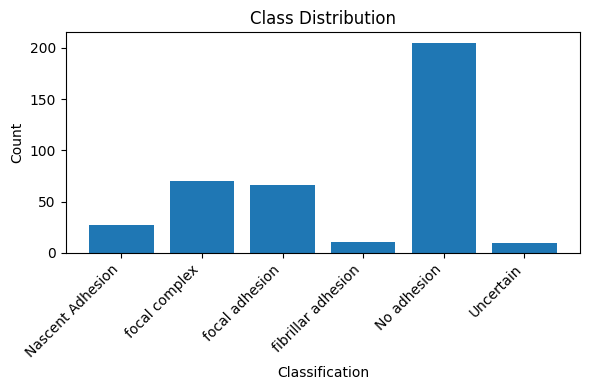

In [14]:
import matplotlib.pyplot as plt
import numpy as np

class_names = classification_label_order
n_classes = len(class_names)

y_enc = lat8_margaret_label_121922["FA_type_id"].dropna().astype(int).values

plt.figure(figsize=(6, 4))

plt.hist(
    y_enc,
    bins=np.arange(n_classes + 1) - 0.5,
    rwidth=0.8
)

plt.xticks(
    np.arange(n_classes),
    class_names,
    rotation=45,
    ha="right"
)

plt.xlabel("Classification")
plt.ylabel("Count")
plt.title("Class Distribution")

plt.tight_layout()
plt.show()


In [91]:
lat8_margaret_label_121922

,Unnamed: 0,unique_ID,lat_d0,lat_d1,lat_d2,lat_d3,lat_d4,lat_d5,lat_d6,lat_d7,UMAP_d0,UMAP_d1,dist_cell_edge,front_flag,Position,classification,group_ID,group,FA_type_id,position_id
0,0,control-f0001x0592y0560ps32.tif,-0.983314,-2.404803,-3.736503,6.555636,0.042419,6.967061,-8.542937,-4.755290,4.961792,-1.905312,51.0,0.0,Cell Body,No adhesion,0,control,4,3
1,1,control-f0001x0688y0848ps32.tif,-4.863095,-3.715334,-3.399110,5.652102,0.032057,8.218933,-11.530948,-4.186346,6.798612,-2.101816,105.0,0.0,Lamella,No adhesion,0,control,4,2
2,2,control-f0001x0592y0592ps32.tif,-1.803649,-2.869361,-1.006975,3.253512,0.877270,5.041645,-6.751046,-2.243623,2.566194,-2.282539,83.0,0.0,Cell Body,No adhesion,0,control,4,3
3,3,control-f0001x0368y0528ps32.tif,-3.296754,-2.140397,1.562945,5.854156,4.291277,12.685116,-13.712293,-2.580447,7.103175,-0.058455,5.0,0.0,Cell Periphery/other,No adhesion,0,control,4,1
4,4,control-f0001x0592y0528ps32.tif,2.648586,3.077546,4.824249,5.175311,1.487612,9.489152,-10.581527,-0.956125,4.539909,0.757580,19.0,0.0,Cell Periphery/other,No adhesion,0,control,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,384,ycomp-f0039x0720y0752ps32.tif,0.990941,-2.684233,1.284537,0.897436,4.290197,10.083295,-12.114593,-7.051551,5.978190,-0.200518,8.0,255.0,Cell Protruding Edge,focal complex,1,ycomp,1,0
385,385,ycomp-f0039x0240y0656ps32.tif,-0.143192,-2.601841,-2.787721,4.788752,3.742576,10.644148,-12.272271,-1.724936,6.268112,-0.823599,12.0,255.0,Cell Periphery/other,Nascent Adhesion,1,ycomp,0,1
386,386,ycomp-f0039x0688y0592ps32.tif,-1.135026,-1.093894,-4.306705,5.795660,-0.412325,9.808274,-6.398516,0.391343,3.894204,-0.520346,171.0,0.0,Lamella,No adhesion,1,ycomp,4,2
387,387,ycomp-f0039x0304y0592ps32.tif,-1.162817,0.986429,1.793646,6.831646,-2.493236,7.423744,-10.250132,3.400178,4.503439,0.089625,120.0,0.0,Lamella,No adhesion,1,ycomp,4,2


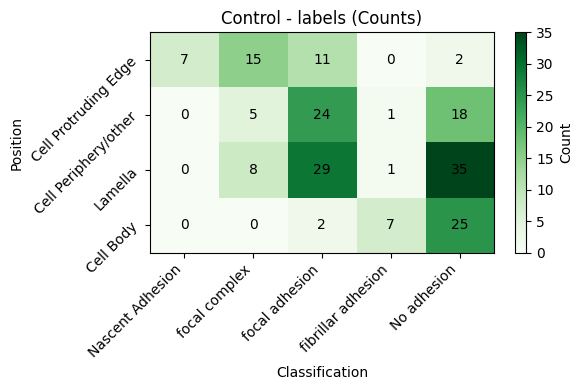

In [ ]:

mask = lat8_margaret_label_121922["group_ID"] ==0

position_ids = range(len(position_label_order))        # 0..4
fa_ids = range(len(classification_label_order))         # e.g. 0..5

ct = pd.crosstab(
    lat8_margaret_label_121922["position_id"][mask],
    lat8_margaret_label_121922["FA_type_id"][mask]
)

ct = ct.reindex(
    index=position_ids,
    columns=fa_ids,
    fill_value=0
)

fig, ax = plt.subplots(figsize=(6, 4))

im = ax.imshow(ct.values[0:4, 0:5], cmap="Greens", aspect="auto")


plt.xticks(
    np.arange(5),
    classification_label_order[:-1],
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(4),
    position_label_order[:-1],
    rotation=45,
    ha="right")


ax.set_xlabel("Classification")
ax.set_ylabel("Position")
ax.set_title("Control - labels (Counts)")

# annotate cells
for i in range(ct.shape[0]-1):
    for j in range(ct.shape[1]-1):
        ax.text(j, i, ct.values[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

In [17]:
indices = np.arange(len(X))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=y_FA_class_enc,   # primary task
    random_state=42
)

X_train = X[train_idx]
X_val   = X[val_idx]

y_FA_class_train = y_FA_class_enc[train_idx]
y_FA_class_val   = y_FA_class_enc[val_idx]

y_position_train = y_position_enc[train_idx]
y_position_val   = y_position_enc[val_idx]


In [18]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])


In [19]:
pipe.fit(X_train, y_FA_class_train)


/home/ldin/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [20]:
classification_label_order

['Nascent Adhesion',
 'focal complex',
 'focal adhesion',
 'fibrillar adhesion',
 'No adhesion',
 'Uncertain']

In [21]:
y_FA_class_pred = pipe.predict(X_val)

print("Validation classification report:")
print(classification_report(
    y_FA_class_val,
    y_FA_class_pred,
    target_names=classification_label_order[:-1]
))


Validation classification report:
                    precision    recall  f1-score   support

  Nascent Adhesion       0.17      0.50      0.25         6
     focal complex       0.50      0.29      0.36        14
    focal adhesion       0.36      0.38      0.37        13
fibrillar adhesion       0.05      0.50      0.10         2
       No adhesion       0.71      0.29      0.41        41

          accuracy                           0.33        76
         macro avg       0.36      0.39      0.30        76
      weighted avg       0.55      0.33      0.38        76



In [22]:
cm = confusion_matrix(y_FA_class_val, y_FA_class_pred)

cm_df = pd.DataFrame(
    cm,
    index=classification_label_order[:-1],
    columns=classification_label_order[:-1]
)

cm_df


,Nascent Adhesion,focal complex,focal adhesion,fibrillar adhesion,No adhesion
Nascent Adhesion,3,2,0,1,0
focal complex,4,4,2,2,2
focal adhesion,1,1,5,3,3
fibrillar adhesion,0,0,1,1,0
No adhesion,10,1,6,12,12


In [23]:
coef = pd.DataFrame(
    pipe.named_steps["clf"].coef_,
    columns=lat_cols,
    index=classification_label_order[:-1]
)

coef


,lat_d0,lat_d1,lat_d2,lat_d3,lat_d4,lat_d5,lat_d6,lat_d7
Nascent Adhesion,-0.186912,-0.567023,-0.142401,0.720936,0.082888,-0.218361,-0.476107,-0.564208
focal complex,-0.024718,0.103051,-0.245713,0.755272,-0.119872,0.754378,0.210216,-0.200639
focal adhesion,-0.178513,0.933925,-0.013559,-0.688798,0.043810,0.194090,-0.198318,0.325999
fibrillar adhesion,0.668782,-0.674895,0.501405,-1.028613,-0.167923,-0.438100,0.914276,0.077962
No adhesion,-0.278639,0.204941,-0.099732,0.241202,0.161097,-0.292008,-0.450068,0.360887


In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_FA_class_val, y_FA_class_pred)
class_names = classification_label_order[:-1]


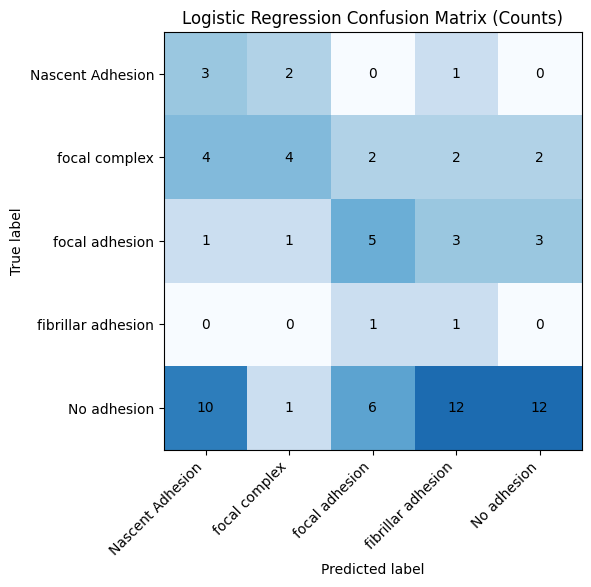

In [25]:
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(np.sqrt(cm),  cmap="Blues",vmax=4.5)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Logistic Regression Confusion Matrix (Counts)")

# annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center")

plt.tight_layout()
plt.show()


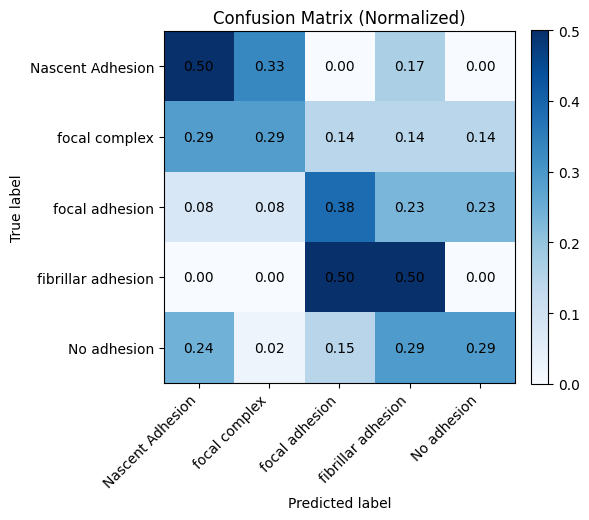

In [26]:
from matplotlib.colors import PowerNorm

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 6))


im = ax.imshow(
    cm_norm,
    cmap="Blues"
)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix (Normalized)")

# annotate cells
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}",
                ha="center", va="center")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


In [27]:
np.sqrt(cm)

array([[1.73205081, 1.41421356, 0.        , 1.        , 0.        ],
       [2.        , 2.        , 1.41421356, 1.41421356, 1.41421356],
       [1.        , 1.        , 2.23606798, 1.73205081, 1.73205081],
       [0.        , 0.        , 1.        , 1.        , 0.        ],
       [3.16227766, 1.        , 2.44948974, 3.46410162, 3.46410162]])

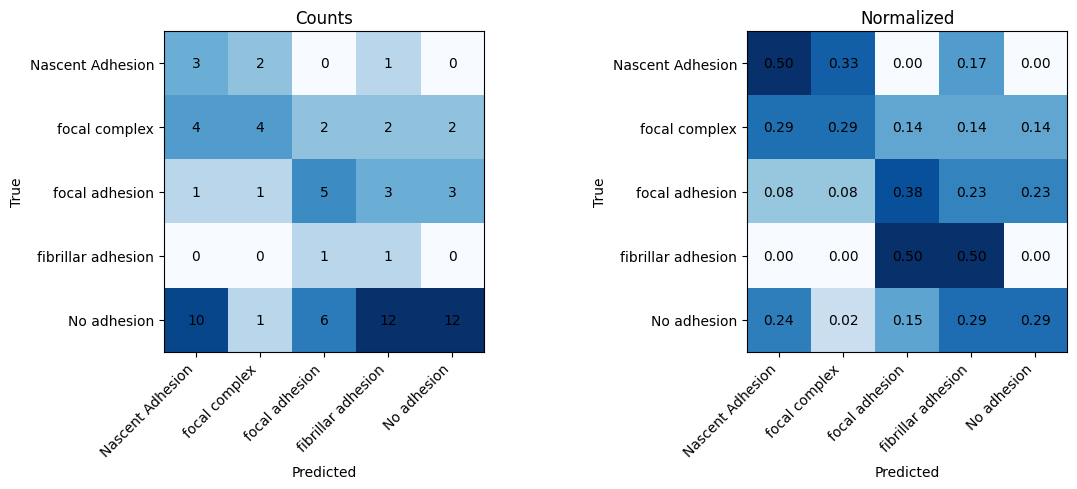

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, mat, title in zip(
    axes,
    [cm, cm_norm],
    ["Counts", "Normalized"]
):
    im = ax.imshow(np.sqrt(mat),   cmap="Blues")
    ax.set_title(title)
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            txt = mat[i, j] if title == "Counts" else f"{mat[i, j]:.2f}"
            ax.text(j, i, txt, ha="center", va="center")

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()


In [29]:
y_FA_class_train_pred = pipe.predict(X_train)
print("Train accuracy:", (y_FA_class_train_pred == y_FA_class_train).mean())


Train accuracy: 0.36303630363036304


# Logistic regression cannot separate samples
Try other higher level ones

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_FA_class_train)

y_FA_class_pred = rf.predict(X_val)
print(classification_report(y_FA_class_val, y_FA_class_pred, target_names=classification_label_order[:-1]))


                    precision    recall  f1-score   support

  Nascent Adhesion       0.00      0.00      0.00         6
     focal complex       0.37      0.50      0.42        14
    focal adhesion       0.50      0.46      0.48        13
fibrillar adhesion       0.00      0.00      0.00         2
       No adhesion       0.68      0.73      0.71        41

          accuracy                           0.57        76
         macro avg       0.31      0.34      0.32        76
      weighted avg       0.52      0.57      0.54        76



/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [31]:
cm = confusion_matrix(y_FA_class_val, y_FA_class_pred)
class_names = classification_label_order[:-1]


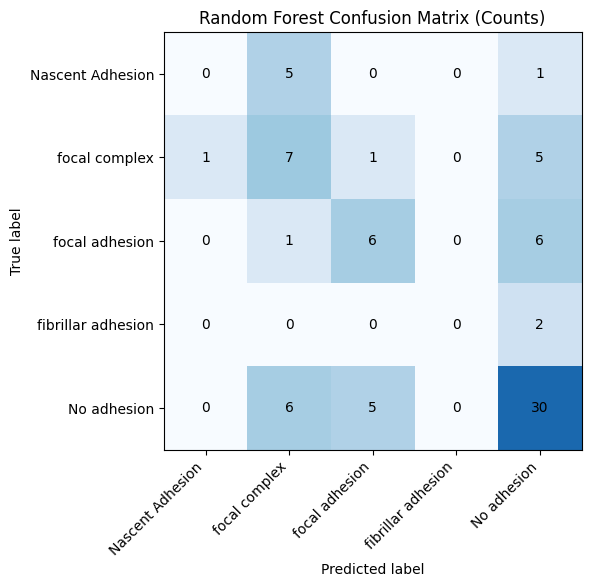

In [32]:
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(np.sqrt(cm),    cmap="Blues",vmax=7)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Random Forest Confusion Matrix (Counts)")

# annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center")

plt.tight_layout()
plt.show()


In [33]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_FA_class_train)

y_FA_class_train_pred = gb.predict(X_train)

y_FA_class_pred = gb.predict(X_val)
print(classification_report(y_FA_class_val, y_FA_class_pred, target_names=classification_label_order[:-1]))


                    precision    recall  f1-score   support

  Nascent Adhesion       0.00      0.00      0.00         6
     focal complex       0.27      0.29      0.28        14
    focal adhesion       0.46      0.46      0.46        13
fibrillar adhesion       0.00      0.00      0.00         2
       No adhesion       0.69      0.76      0.72        41

          accuracy                           0.54        76
         macro avg       0.28      0.30      0.29        76
      weighted avg       0.50      0.54      0.52        76



/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [34]:
X_val.shape

(76, 8)

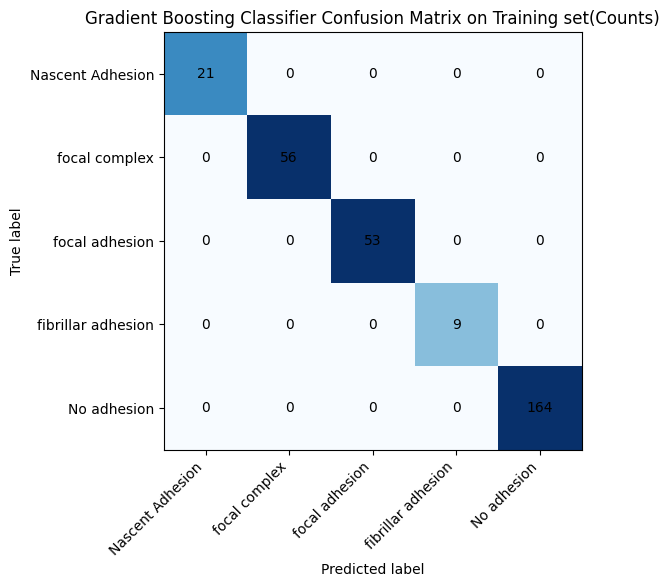

In [35]:
cm = confusion_matrix(y_FA_class_train, y_FA_class_train_pred)
class_names = classification_label_order[:-1]
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(np.sqrt(cm), cmap="Blues",vmax=7)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Gradient Boosting Classifier Confusion Matrix on Training set(Counts)")

# annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center")

plt.tight_layout()
plt.show()


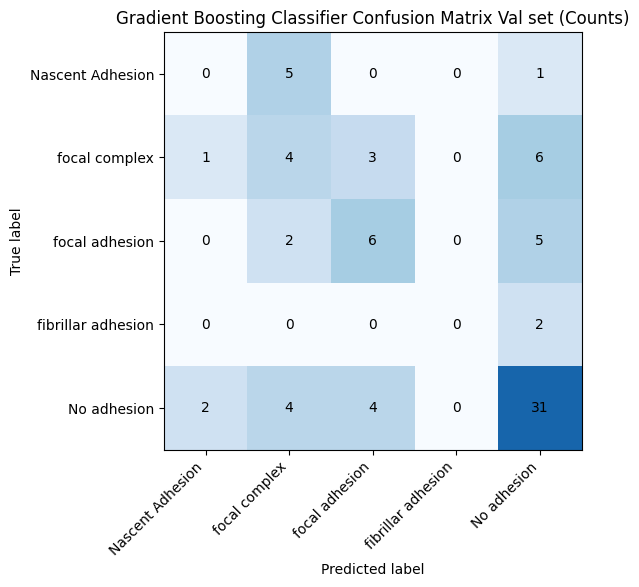

In [36]:

cm = confusion_matrix(y_FA_class_val, y_FA_class_pred)
class_names = classification_label_order[:-1]
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(np.sqrt(cm), cmap="Blues",vmax=7)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Gradient Boosting Classifier Confusion Matrix Val set (Counts)")

# annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center")

plt.tight_layout()
plt.show()


In [37]:
lat_cols = [f"lat_d{i}" for i in range(8)]

X_all = patch_label_df[lat_cols].values
umap_all_d0 = patch_label_df['UMAP_d0']
umap_all_d1 = patch_label_df['UMAP_d1']
front_flag_all = patch_label_df['front_flag']

y_FA_class_all_pred = gb.predict(X_all)

In [38]:
front_flag_all = patch_label_df['front_flag']

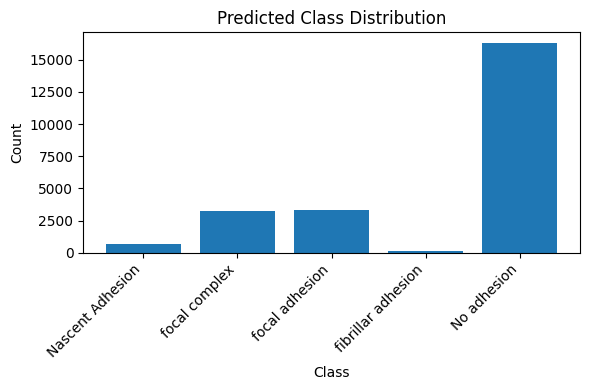

In [39]:

class_names = classification_label_order[:-1]
n_classes = len(class_names)

plt.figure(figsize=(6, 4))

plt.hist(
    y_FA_class_all_pred,
    bins=np.arange(n_classes + 1) - 0.5,
    rwidth=0.8
)

plt.xticks(
    np.arange(n_classes),
    class_names,
    rotation=45,
    ha="right"
)

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Predicted Class Distribution")

plt.tight_layout()
plt.show()


In [40]:
# id -> color (via label)
fa_id_to_color = {
    i: classification_label_to_color[label]
    for i, label in enumerate(classification_label_order)
}

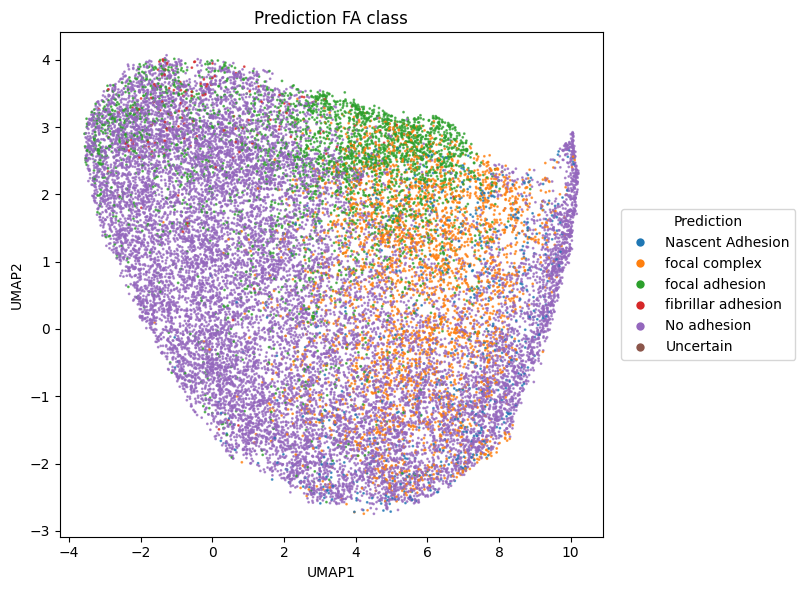

In [41]:
# plot the predictions with Gradient Boosting Classifier
mask = y_FA_class_all_pred > -1

pred_ids = y_FA_class_all_pred[mask].astype(int)

pred_colors = [fa_id_to_color[i] for i in pred_ids]

plt.figure(figsize=(10, 6))

plt.scatter(
    umap_all_d0[mask],
    umap_all_d1[mask],
    c=pred_colors,
    alpha=0.7,
    s=1
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Prediction FA class")

from matplotlib.lines import Line2D

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=classification_label_to_color[label],
        markeredgecolor="none",
        markersize=6,
        label=label
    )
    for label in classification_label_order
]

plt.legend(
    handles=handles,
    title="Prediction",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()



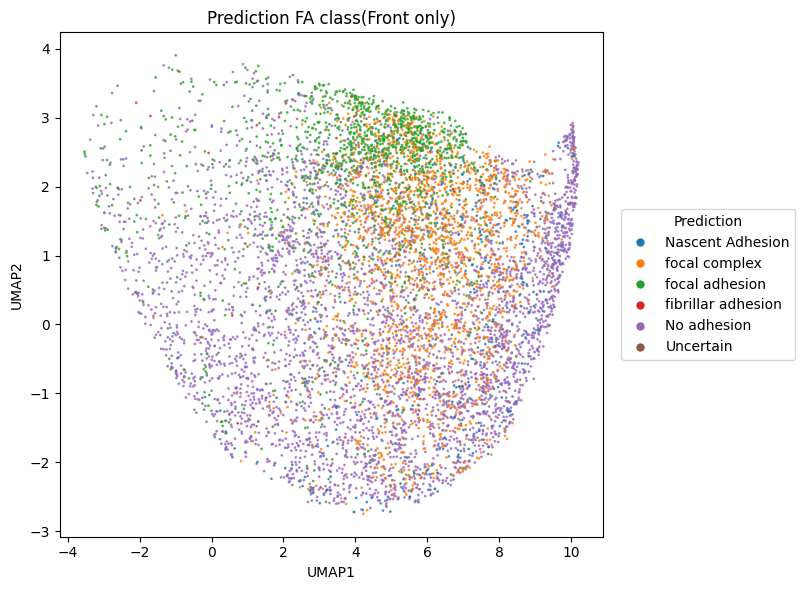

In [42]:

mask = front_flag_all > 0

pred_ids = y_FA_class_all_pred[mask].astype(int)

pred_colors = [fa_id_to_color[i] for i in pred_ids]

plt.figure(figsize=(10, 6))

plt.scatter(
    umap_all_d0[mask],
    umap_all_d1[mask],
    c=pred_colors,
    alpha=0.7,
    s=1
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Prediction FA class(Front only)")

from matplotlib.lines import Line2D

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=classification_label_to_color[label],
        markeredgecolor="none",
        markersize=6,
        label=label
    )
    for label in classification_label_order
]

plt.legend(
    handles=handles,
    title="Prediction",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()



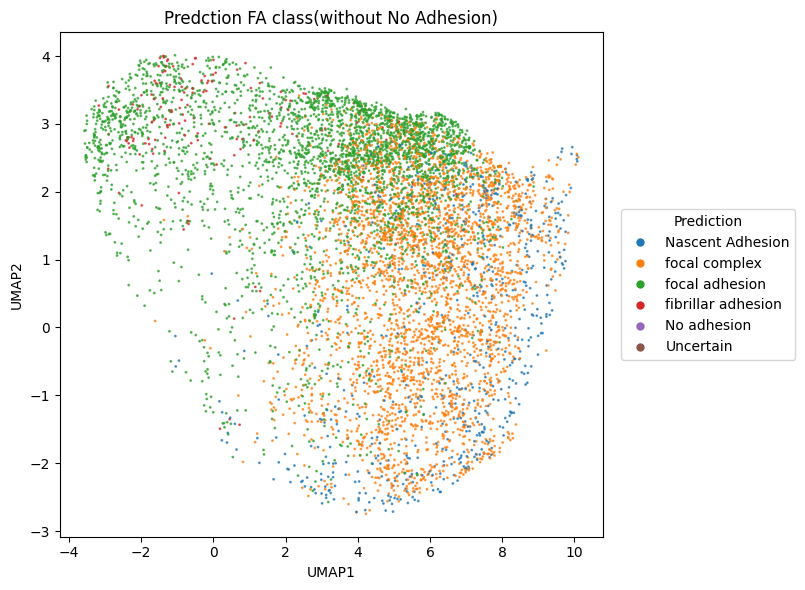

In [43]:
# plot without the  "no adhesion group"
mask = y_FA_class_all_pred!=4

pred_ids = y_FA_class_all_pred[mask].astype(int)

pred_colors = [fa_id_to_color[i] for i in pred_ids]
plt.figure(figsize=(10, 6))

plt.scatter(
    umap_all_d0[mask],
    umap_all_d1[mask],
    c=pred_colors,
    alpha=0.7,
    s=1
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Predction FA class(without No Adhesion)")

from matplotlib.lines import Line2D

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=classification_label_to_color[label],
        markeredgecolor="none",
        markersize=6,
        label=label
    )
    for label in classification_label_order
]

plt.legend(
    handles=handles,
    title="Prediction",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()



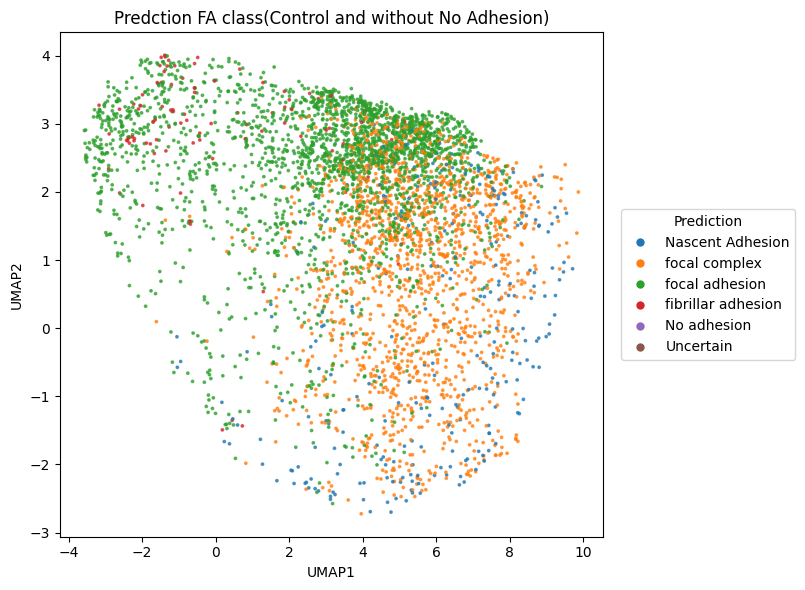

In [44]:
# plot without the  "no adhesion group"
mask = np.logical_and(y_FA_class_all_pred!=4 , patch_label_df['group'].values == 'control')>0

pred_ids = y_FA_class_all_pred[mask].astype(int)

pred_colors = [fa_id_to_color[i] for i in pred_ids]
plt.figure(figsize=(10, 6))

plt.scatter(
    umap_all_d0[mask],
    umap_all_d1[mask],
    c=pred_colors,
    alpha=0.7,
    s=3
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Predction FA class(Control and without No Adhesion)")

from matplotlib.lines import Line2D

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=classification_label_to_color[label],
        markeredgecolor="none",
        markersize=6,
        label=label
    )
    for label in classification_label_order
]

plt.legend(
    handles=handles,
    title="Prediction",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()



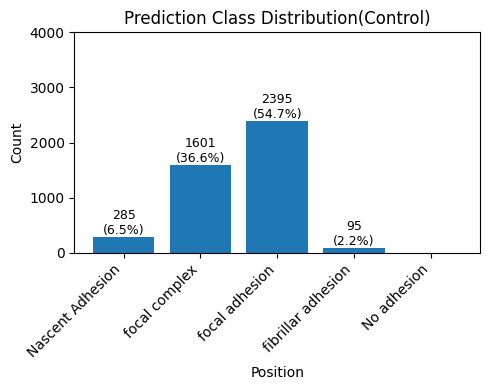

In [126]:
# plot without the  "no adhesion group"
mask = np.logical_and(y_FA_class_all_pred!=4, patch_label_df['group'].values == 'control')>0

pred_ids = y_FA_class_all_pred[mask]


plt.figure(figsize=(5, 4))

counts, bins, patches = plt.hist(
    pred_ids,
    bins=np.arange(n_classes + 1) - 0.5,
    rwidth=0.8
)

total = counts.sum()

# Add percentage labels
for count, patch in zip(counts, patches):
    if count > 0:
        percentage = 100 * count / total
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        # inside the same loop
        plt.text(
            x, y,
            f"{int(count)}\n({percentage:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=9
        )


plt.xticks(
    np.arange(n_classes),
    class_names,
    rotation=45,
    ha="right"
)

plt.xlabel("Position")
plt.ylabel("Count")
plt.title("Prediction Class Distribution(Control)")
plt.ylim([0,4000])
plt.tight_layout()
plt.show()

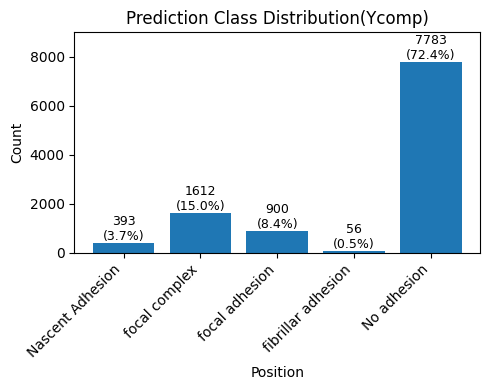

In [46]:
# plot without the  "no adhesion group"
mask = np.logical_and(y_FA_class_all_pred!=40 , patch_label_df['group'].values == 'ycomp')>0

pred_ids = y_FA_class_all_pred[mask]


plt.figure(figsize=(5, 4))

counts, bins, patches = plt.hist(
    pred_ids,
    bins=np.arange(n_classes + 1) - 0.5,
    rwidth=0.8
)

total = counts.sum()

# Add percentage labels
for count, patch in zip(counts, patches):
    if count > 0:
        percentage = 100 * count / total
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        # inside the same loop
        plt.text(
            x, y,
            f"{int(count)}\n({percentage:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=9
        )


plt.xticks(
    np.arange(n_classes),
    class_names,
    rotation=45,
    ha="right"
)

plt.xlabel("Position")
plt.ylabel("Count")
plt.title("Prediction Class Distribution(Ycomp)")
plt.ylim([0,9000])
plt.tight_layout()
plt.show()

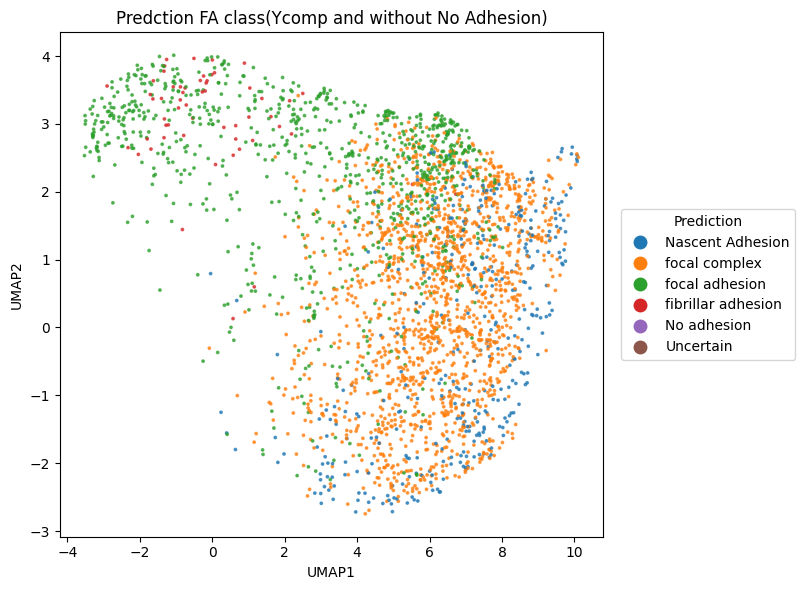

In [47]:
# plot without the  "no adhesion group"
mask = np.logical_and(y_FA_class_all_pred!=4 , patch_label_df['group'].values == 'ycomp')>0

pred_ids = y_FA_class_all_pred[mask].astype(int)

pred_colors = [fa_id_to_color[i] for i in pred_ids]
plt.figure(figsize=(10, 6))

plt.scatter(
    umap_all_d0[mask],
    umap_all_d1[mask],
    c=pred_colors,
    alpha=0.7,
    s=3
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Predction FA class(Ycomp and without No Adhesion)")

from matplotlib.lines import Line2D

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=classification_label_to_color[label],
        markeredgecolor="none",
        markersize=10,
        label=label
    )
    for label in classification_label_order
]

plt.legend(
    handles=handles,
    title="Prediction",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()



In [48]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_clf = LinearDiscriminantAnalysis(
    solver="svd"   # default, good for small-sample cases
)

lda_clf.fit(X_train, y_FA_class_train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [49]:
y_pred_LDA_train = lda_clf.predict(X_train)
y_pred_LDA_val = lda_clf.predict(X_val)


In [50]:
y_pred_LDA_all = lda_clf.predict(X_all)

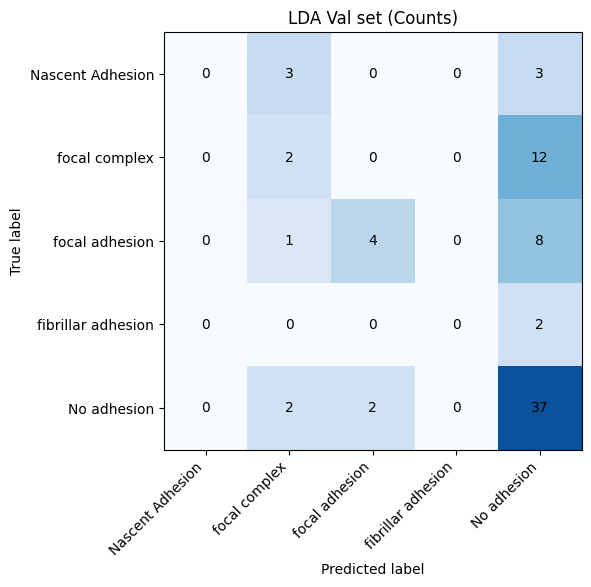

In [51]:

cm = confusion_matrix(y_FA_class_val, y_pred_LDA_val)
class_names = classification_label_order[:-1]
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(np.sqrt(cm), cmap="Blues",vmax=7)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("LDA Val set (Counts)")

# annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center")

plt.tight_layout()
plt.show()


In [52]:
lda_2d = LinearDiscriminantAnalysis(
    n_components=2,
    solver="svd"
)

lda_2d.fit(X_train, y_FA_class_train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,2
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [53]:
lda_3d = LinearDiscriminantAnalysis(
    n_components=3,
    solver="svd"
)

lda_3d.fit(X_train, y_FA_class_train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,3
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [54]:
X_lda_all_3d = lda_3d.transform(X_all) 

In [55]:
X_lda_all_3d

array([[-5.49934538e+00,  2.48500969e+00, -3.84725163e+00],
       [ 1.08200156e+00, -6.55618627e-01,  1.10370373e+00],
       [ 2.11039850e-01,  8.33546101e-01,  1.48675398e+00],
       ...,
       [ 7.06853665e-02, -4.04729528e-01,  3.78172080e-01],
       [ 8.16783736e-01,  2.79987683e-01,  2.13173180e-03],
       [ 5.26581381e-01,  1.18057855e+00, -1.92721037e+00]])

In [56]:
lat8_margaret_label_121922.columns

Index(['Unnamed: 0', 'unique_ID', 'lat_d0', 'lat_d1', 'lat_d2', 'lat_d3',
       'lat_d4', 'lat_d5', 'lat_d6', 'lat_d7', 'UMAP_d0', 'UMAP_d1',
       'dist_cell_edge', 'front_flag', 'Position', 'classification',
       'group_ID', 'group', 'FA_type_id', 'position_id'],
      dtype='object')

In [57]:
patch_label_df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'ctrl_y_str', 'crop_img_filename',
       'group_labels', 'UMAP_d0', 'UMAP_d1', 'DBSCAN_labels', 'kmeans_labels',
       'vinculin_intensity', 'pax_intensity', 'actin_intensity',
       'dist_cell_edge', 'front_flag', 'lat_d0', 'lat_d1', 'lat_d2', 'lat_d3',
       'lat_d4', 'lat_d5', 'lat_d6', 'lat_d7', 'group', 'unique_ID'],
      dtype='object')

In [58]:
X_labeled = lat8_margaret_label_121922[lat_cols].values

X_lda_all_2d = lda_2d.transform(X_all)   
X_lda_train_2d = lda_2d.transform(X_train)   
X_lda_val_2d = lda_2d.transform(X_val)   
X_lda_labeled_2d = lda_2d.transform(X_labeled)   



In [59]:
label_cols = [
    "unique_ID",
    "Position",
    "classification"
]

labels_df = lat8_margaret_label_121922[label_cols].copy()
patch_with_labels = patch_label_df.merge(
    labels_df,
    on="unique_ID",
    how="left"
)
is_labeled = patch_with_labels["Position"].notna()
n_labeled = is_labeled.sum()
n_unlabeled = (~is_labeled).sum()

print(f"Labeled: {n_labeled}")
print(f"Unlabeled: {n_unlabeled}")


Labeled: 389
Unlabeled: 23267


In [60]:
X_lda_labeled_2d.shape

(389, 2)

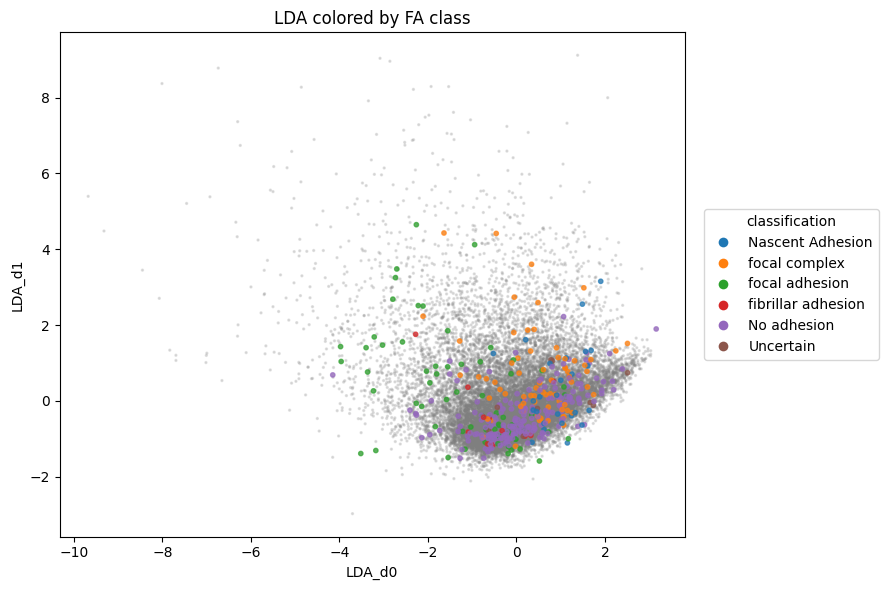

In [61]:
plt.figure(figsize=(9, 6))

plt.scatter(X_lda_all_2d[:,0] , X_lda_all_2d[:,1] , c=5-patch_label_df['group_labels']*0+2, cmap='tab20', alpha=0.2, s=2, vmin=0, vmax=10)  

plt.scatter(
    X_lda_labeled_2d[:,0],
    X_lda_labeled_2d[:,1],
    c=lat8_margaret_label_121922["classification"].map(classification_label_to_color),
    s=10,
    alpha=0.7
)

plt.xlabel("LDA_d0")
plt.ylabel("LDA_d1")
plt.title("LDA colored by FA class")

# legend
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=classification_label_to_color[label],
           markeredgecolor="none",
           markersize=7, label=label)
    for label in classification_label_order
]
plt.legend(
    handles=handles,
    title="classification",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)
plt.tight_layout()
plt.show()

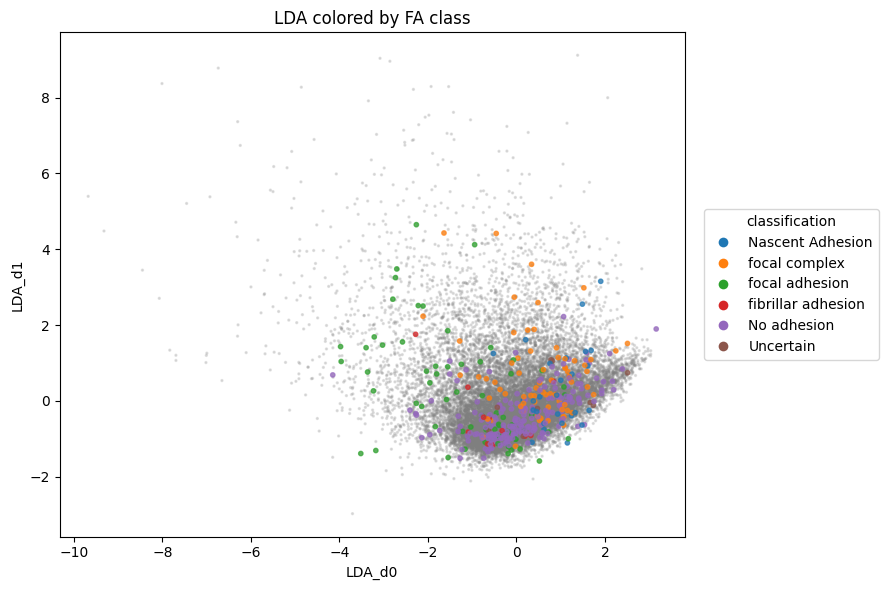

In [62]:
plt.figure(figsize=(9, 6))

plt.scatter(X_lda_all_2d[:,0] , X_lda_all_2d[:,1] , c=5-patch_label_df['group_labels']*0+2, cmap='tab20', alpha=0.2, s=2, vmin=0, vmax=10)  

plt.scatter(
    X_lda_labeled_2d[:,0],
    X_lda_labeled_2d[:,1],
    c=lat8_margaret_label_121922["classification"].map(classification_label_to_color),
    s=10,
    alpha=0.7
)

plt.xlabel("LDA_d0")
plt.ylabel("LDA_d1")
plt.title("LDA colored by FA class")

# legend
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=classification_label_to_color[label],
           markeredgecolor="none",
           markersize=7, label=label)
    for label in classification_label_order
]
plt.legend(
    handles=handles,
    title="classification",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)
plt.tight_layout()
plt.show()

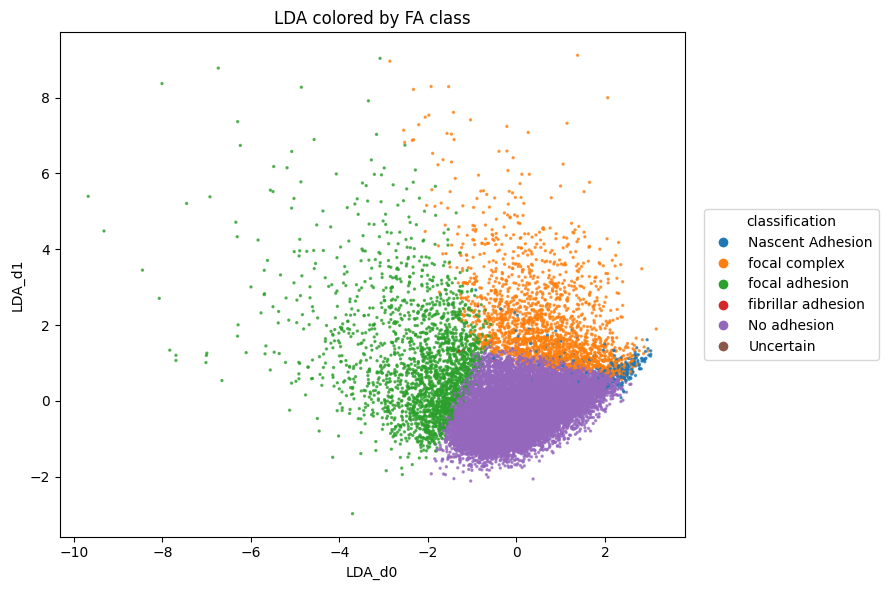

In [63]:
plt.figure(figsize=(9, 6))


pred_colors = [fa_id_to_color[i] for i in y_pred_LDA_all]

plt.scatter(
    X_lda_all_2d[:, 0],
    X_lda_all_2d[:, 1],
    c=pred_colors,
    s=2,
    alpha=0.7
)

plt.xlabel("LDA_d0")
plt.ylabel("LDA_d1")
plt.title("LDA colored by FA class")

# legend
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=classification_label_to_color[label],
           markeredgecolor="none",
           markersize=7, label=label)
    for label in classification_label_order
]
plt.legend(
    handles=handles,
    title="classification",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)
plt.tight_layout()
plt.show()

<Figure size 900x600 with 0 Axes>

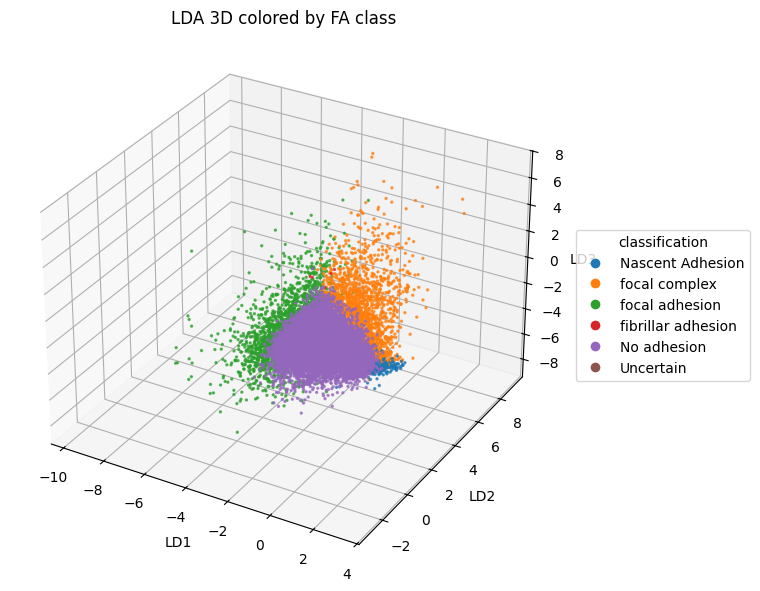

In [64]:
plt.figure(figsize=(9, 6))


pred_colors = [fa_id_to_color[i] for i in y_pred_LDA_all]

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_lda_all_3d[:, 0],
    X_lda_all_3d[:, 1],
    X_lda_all_3d[:, 2],
    c=pred_colors,
    s=2,
    alpha=0.7
)

ax.set_xlabel("LD1")
ax.set_ylabel("LD2")
ax.set_zlabel("LD3")


plt.title("LDA 3D colored by FA class")

# legend
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=classification_label_to_color[label],
           markeredgecolor="none",
           markersize=7, label=label)
    for label in classification_label_order
]
plt.legend(
    handles=handles,
    title="classification",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)
plt.tight_layout()
plt.show()

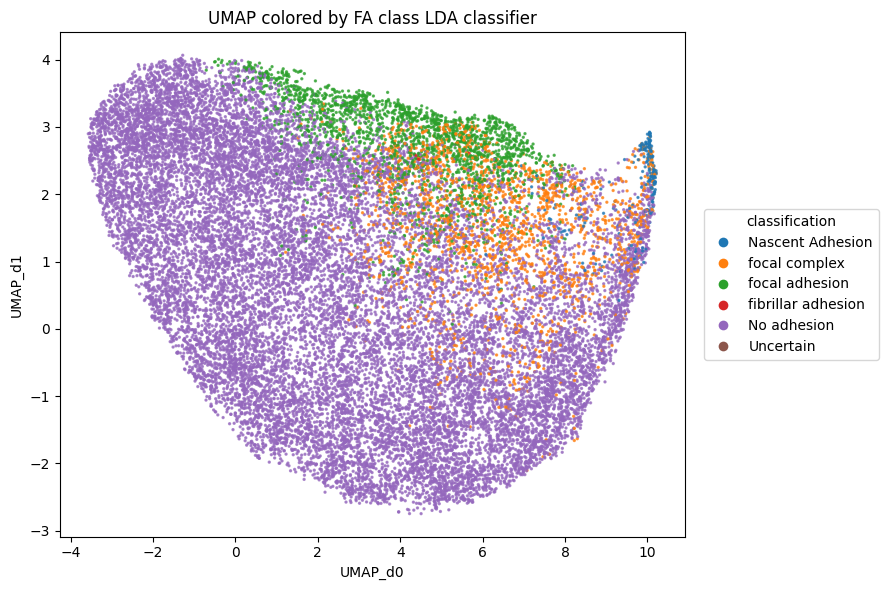

In [65]:
plt.figure(figsize=(9, 6))


pred_colors = [fa_id_to_color[i] for i in y_pred_LDA_all]

plt.scatter(
    latents_lat8_2d[:, 0],
    latents_lat8_2d[:, 1],   
    c=pred_colors,
    s=2,
    alpha=0.7
)

plt.xlabel("UMAP_d0")
plt.ylabel("UMAP_d1")
plt.title("UMAP colored by FA class LDA classifier")

# legend
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=classification_label_to_color[label],
           markeredgecolor="none",
           markersize=7, label=label)
    for label in classification_label_order
]
plt.legend(
    handles=handles,
    title="classification",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)
plt.tight_layout()
plt.show()

In [66]:
y_position_all_pred = joblib.load(os.path.join(root_dir, "y_position_all_pred.pkl"))

In [67]:
y_position_all_pred.shape

(23656,)

In [68]:
y_FA_class_all_pred.shape

(23656,)

In [69]:
ct_pred = pd.crosstab(
    y_position_all_pred, y_FA_class_all_pred)


In [137]:
pax_MSE_df = pd.read_csv(os.path.join(root_dir,"pax_MSE_df.csv"))

In [89]:
patch_label_df['FA_class_based_pred'] = y_FA_class_all_pred
patch_label_df['position_based_pred'] = y_position_all_pred

patch_label_df.to_csv(os.path.join(root_dir,"patch_label_df_FAclass_position_GB_pred.csv"))

In [87]:
patch_label_df.shape

(23656, 26)

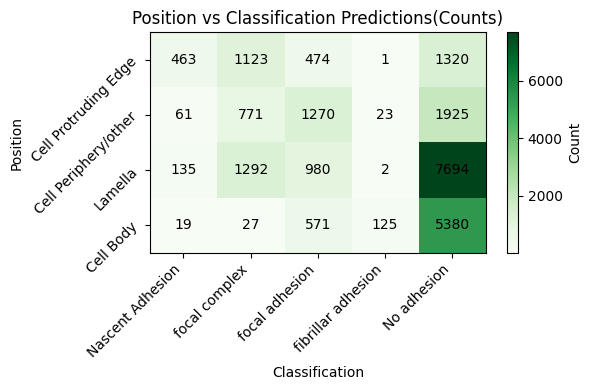

In [71]:

fig, ax = plt.subplots(figsize=(6, 4))

im = ax.imshow(ct_pred.values[0:4, 0:5], cmap="Greens", aspect="auto")


plt.xticks(
    np.arange(5),
    classification_label_order[:-1],
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(4),
    position_label_order[:-1],
    rotation=45,
    ha="right")


ax.set_xlabel("Classification")
ax.set_ylabel("Position")
ax.set_title("Position vs Classification Predictions(Counts)")

# annotate cells
for i in range(ct_pred.shape[0]):
    for j in range(ct_pred.shape[1]):
        ax.text(j, i, ct_pred.values[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

In [72]:
y_position_enc = joblib.load(os.path.join(root_dir, "y_position_enc.pkl"))


In [73]:
y_FA_class_enc.shape

(379,)

In [74]:
lat8_margaret_label_121922.columns

Index(['Unnamed: 0', 'unique_ID', 'lat_d0', 'lat_d1', 'lat_d2', 'lat_d3',
       'lat_d4', 'lat_d5', 'lat_d6', 'lat_d7', 'UMAP_d0', 'UMAP_d1',
       'dist_cell_edge', 'front_flag', 'Position', 'classification',
       'group_ID', 'group', 'FA_type_id', 'position_id'],
      dtype='object')

In [75]:
position_labels = lat8_margaret_label_121922["position_id"]
FA_class_labels = lat8_margaret_label_121922["FA_type_id"]

In [76]:
ct_label= pd.crosstab(
    position_labels, FA_class_labels    
)

In [77]:
ct_label.shape

(5, 6)

In [78]:
ct_label.iloc[0:4, 0:3]

FA_type_id,0,1,2
position_id,,,
0,23,35,11
1,3,14,24
2,0,21,29
3,1,0,2


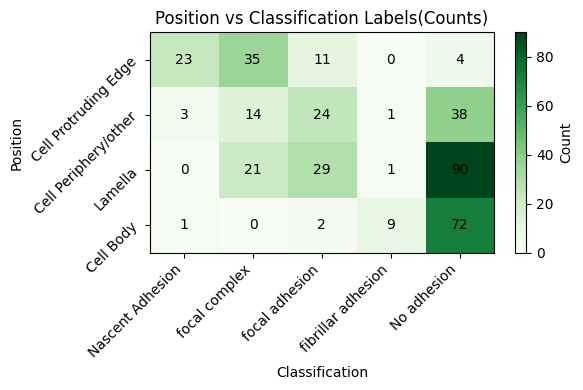

In [79]:
# plt.imshow(ct_label.iloc[0:4, 0:5],cmap="Greens")

fig, ax = plt.subplots(figsize=(6, 4))

im = ax.imshow(ct_label.values[0:4, 0:5], cmap="Greens", aspect="auto")


plt.xticks(
    np.arange(5),
    classification_label_order[:-1],
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(4),
    position_label_order[:-1],
    rotation=45,
    ha="right")


ax.set_xlabel("Classification")
ax.set_ylabel("Position")
ax.set_title("Position vs Classification Labels(Counts)")

# annotate cells
for i in range(ct_label.shape[0]-1):
    for j in range(ct_label.shape[1]-1):
        ax.text(j, i, ct_label.values[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

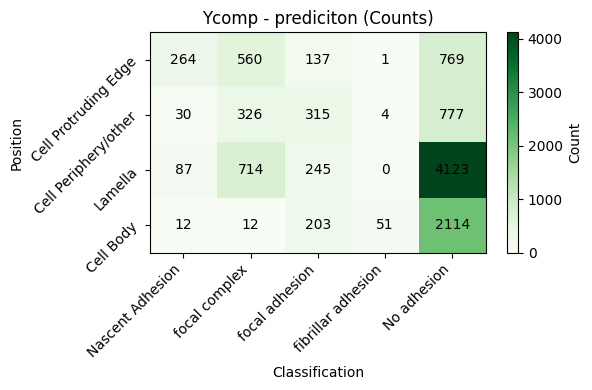

In [122]:

mask = patch_label_df["group"] =='ycomp'

position_ids = range(len(position_label_order))        # 0..4
fa_ids = range(len(classification_label_order))         # e.g. 0..5


ct = pd.crosstab(
    y_position_all_pred[mask],
    y_FA_class_all_pred[mask]
)

ct = ct.reindex(
    index=position_ids,
    columns=fa_ids,
    fill_value=0
)

fig, ax = plt.subplots(figsize=(6, 4))

im = ax.imshow(ct.values[0:4, 0:5], cmap="Greens", aspect="auto")


plt.xticks(
    np.arange(5),
    classification_label_order[:-1],
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(4),
    position_label_order[:-1],
    rotation=45,
    ha="right")


ax.set_xlabel("Classification")
ax.set_ylabel("Position")
ax.set_title("Ycomp - prediciton (Counts)")

# annotate cells
for i in range(ct.shape[0]-1):
    for j in range(ct.shape[1]-1):
        ax.text(j, i, ct.values[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

/tmp/ipykernel_779487/3780949112.py:9: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  combo_codes, combo_categories = pd.factorize(combo_labels)
/tmp/ipykernel_779487/3780949112.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", n_combo)


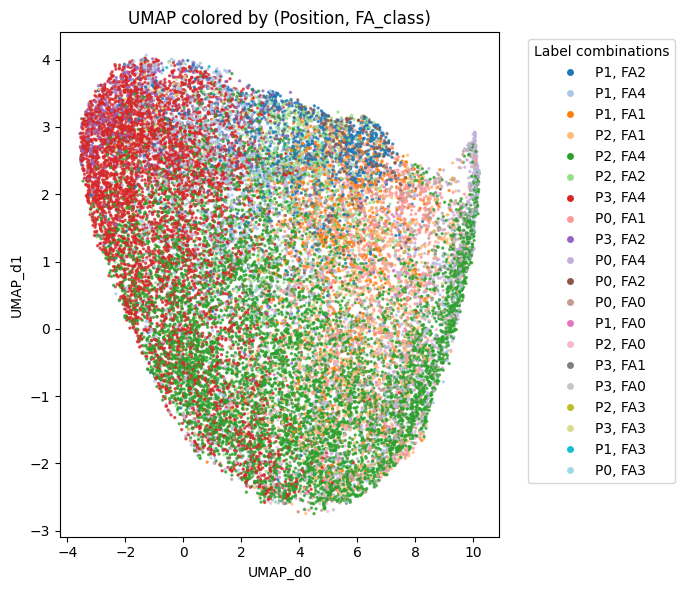

In [80]:
y_position_all_pred
y_FA_class_all_pred

import pandas as pd

combo_labels = list(
    zip(y_position_all_pred, y_FA_class_all_pred)
)
combo_codes, combo_categories = pd.factorize(combo_labels)
import matplotlib.pyplot as plt
import numpy as np

n_combo = len(combo_categories)
cmap = plt.cm.get_cmap("tab20", n_combo)

colors = cmap(combo_codes)
plt.figure(figsize=(7, 6))

plt.scatter(
    umap_all_d0,
    umap_all_d1,
    c=colors,
    s=2,
    alpha=0.7
)

plt.xlabel("UMAP_d0")
plt.ylabel("UMAP_d1")
plt.title("UMAP colored by (Position, FA_class)")

from matplotlib.lines import Line2D

legend_elements = []
for code, (pos, fa) in enumerate(combo_categories):
    legend_elements.append(
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            label=f"P{pos}, FA{fa}",
            markerfacecolor=cmap(code),
            markersize=6
        )
    )

plt.legend(
    handles=legend_elements,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    title="Label combinations"
)


plt.tight_layout()


plt.show()





In [81]:
pos_labels = np.array(position_label_order)[y_position_all_pred]
fa_labels = np.array(classification_label_order)[y_FA_class_all_pred]

In [82]:
import itertools

classification_label_order = [
    "Nascent Adhesion",
    "focal complex",
    "focal adhesion",
    "fibrillar adhesion",
    "No adhesion",
    "Uncertain",
]
position_label_order = [
    "Cell Protruding Edge",
    "Cell Periphery/other",
    "Lamella",
    "Cell Body",
    "No Category/uncertain",
]

# colormap with enough distinct colors
cmap = plt.cm.get_cmap("tab10", n_combo)

combo_to_color = {
    combo: cmap(i)
    for i, combo in enumerate(combo_labels)
}


# choose the combinations you want to display (use your real label strings)
keep_combos = {
    ("Cell Protruding Edge", "Nascent Adhesion"),
    ("Cell Protruding Edge",  "focal complex"),
    ("Cell Periphery/other",  "focal complex"),
    ("Lamella",  "focal complex"),
    ("Cell Protruding Edge",  "focal adhesion"),
    ("Cell Periphery/other",  "focal adhesion"),
    ("Cell Body",  "fibrillar adhesion"),     
    ("Lamella",  "focal adhesion"),  
    ("Cell Periphery/other",  "No adhesion"),  
    ("Lamella",  "No adhesion"),  
    ("Cell Body",  "No adhesion"),  
    # add more...
}
combo_labels = list(keep_combos)

combo_colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#17becf", "#bcbd22", "#aec7e8",
    "#ffbb78",
]

combo_to_color = {
    combo: combo_colors[i]
    for i, combo in enumerate(combo_labels)
}

pred_colors = [
    combo_to_color[(p, f)]
    for p, f in zip(pos_labels, fa_labels)
    if (p, f) in combo_to_color
]




/tmp/ipykernel_779487/4227884891.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", n_combo)


In [83]:
len(pred_colors)

21497

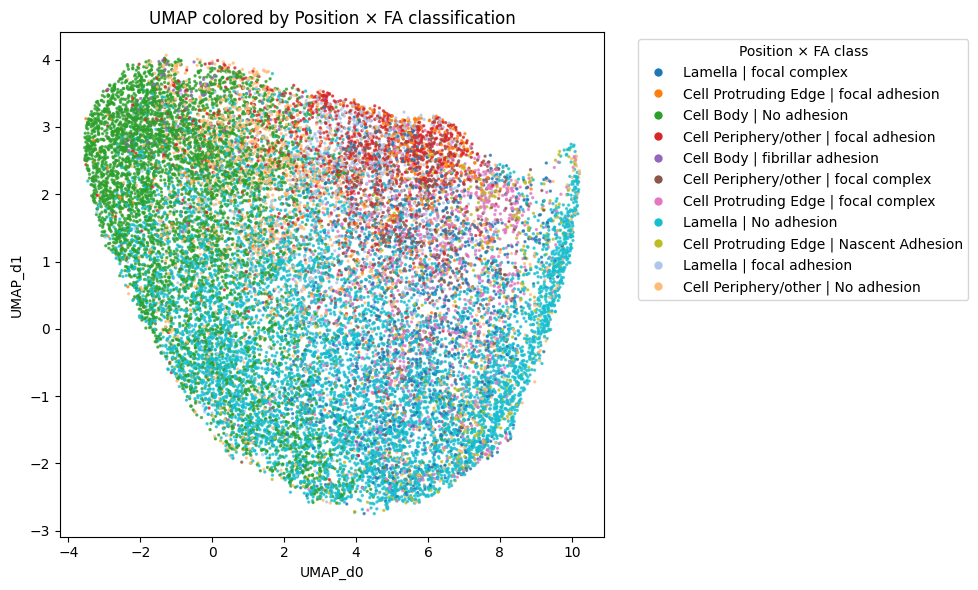

In [84]:
mask_keep = np.array([(p, f) in keep_combos for p, f in zip(pos_labels, fa_labels)])


plt.figure(figsize=(10, 6))

plt.scatter(
    umap_all_d0[mask_keep],
    umap_all_d1[mask_keep],
    c=np.array(pred_colors),
    s=2,
    alpha=0.7
)   

plt.xlabel("UMAP_d0")
plt.ylabel("UMAP_d1")
plt.title("UMAP colored by Position × FA classification")
from matplotlib.lines import Line2D



present_combos = [
    (p, f)
    for (p, f) in combo_to_color.keys()
    if (p, f) in set(zip(pos_labels[mask_keep], fa_labels[mask_keep]))
]
from matplotlib.lines import Line2D

legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        label=f"{p} | {f}",
        markerfacecolor=combo_to_color[(p, f)],
        markeredgecolor="none",
        markersize=6
    )
    for (p, f) in present_combos
]
plt.legend(
    handles=legend_elements,
    title="Position × FA class",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


In [85]:
mask_keep

array([ True,  True,  True, ...,  True,  True, False])